## 🏆 IPL (2008–2023): Exploring Cricket Through Data

Pandas → Turns messy data into clean, structured tables like a pro.

NumPy → Handles heavy math and arrays at lightning speed ⚡


Matplotlib → Brings data to life with powerful visuals and graphs 🎯

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px


## 📂 Loading the IPL Dataset

In this step, we load the IPL dataset (2008–2023) using Pandas and preview the first few rows to understand its structure.

In [2]:
ipl = pd.read_csv("Ipl 2008 to 2023 Dataset.csv")
ipl.head()

,Unnamed: 0,match_id,season,team1,team2,toss_winner,toss_decision,match_winner,winner_wickets,winner_runs,player_of_match,venue,outcome,method,eliminator,team1_win_percentage_against_team2,avg_1st_innings,avg_2nd_innings
0,0,1024,2023,Gujarat Titans,Chennai Super Kings,Chennai Super Kings,field,Chennai Super Kings,5.0,0.0,DP Conway,"Narendra Modi Stadium, Ahmedabad",Normal,D/L,NaN,60.00,177.0,161.0
1,1,1023,2023,Gujarat Titans,Mumbai Indians,Mumbai Indians,field,Gujarat Titans,0.0,47.5,Shubman Gill,"Narendra Modi Stadium, Ahmedabad",Normal,Not D/L,NaN,50.00,177.0,161.0
2,2,1022,2023,Lucknow Super Giants,Mumbai Indians,Mumbai Indians,bat,Mumbai Indians,0.0,47.5,Akash Madhwal,"MA Chidambaram Stadium, Chepauk, Chennai",Normal,Not D/L,NaN,75.00,163.0,150.0
3,3,1021,2023,Gujarat Titans,Chennai Super Kings,Gujarat Titans,field,Chennai Super Kings,0.0,15.0,RD Gaikwad,"MA Chidambaram Stadium, Chepauk, Chennai",Normal,Not D/L,NaN,60.00,163.0,150.0
4,4,1020,2023,Gujarat Titans,Royal Challengers Bangalore,Gujarat Titans,field,Gujarat Titans,6.0,0.0,Shubman Gill,"M Chinnaswamy Stadium, Bengaluru",Normal,Not D/L,NaN,66.67,171.0,153.0


In this step, we clean the column names by removing extra spaces, converting them to lowercase, and replacing spaces with underscores for better consistency and easier access.

In [3]:
ipl.columns = ipl.columns.str.strip().str.lower().str.replace(" ", "_")

In [4]:
ipl.columns

Index(['unnamed:_0', 'match_id', 'season', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'match_winner', 'winner_wickets', 'winner_runs',
       'player_of_match', 'venue', 'outcome', 'method', 'eliminator',
       'team1_win_percentage_against_team2', 'avg_1st_innings',
       'avg_2nd_innings'],
      dtype='object')

In [5]:
ipl.shape

(1024, 18)

## Remove unnecessary columns

In [6]:
drop_columns = ['unnamed:_0', 'match_id', 'eliminator', 'method', 'outcome']

# Create a cleaned dataset by dropping irrelevant columns
ipl_cleaned = ipl.drop(columns=drop_columns, inplace=True)

print("The dataset now contains only relevant and useful columns.")

The dataset now contains only relevant and useful columns.


## 📊 Dataset Information

Here, we check the structure of the dataset, including column names, data types, and missing values to understand the data better.

In [7]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   season                              1024 non-null   int64  
 1   team1                               1024 non-null   object 
 2   team2                               1024 non-null   object 
 3   toss_winner                         1024 non-null   object 
 4   toss_decision                       1024 non-null   object 
 5   match_winner                        1005 non-null   object 
 6   winner_wickets                      1024 non-null   float64
 7   winner_runs                         1024 non-null   float64
 8   player_of_match                     1019 non-null   object 
 9   venue                               1024 non-null   object 
 10  team1_win_percentage_against_team2  1024 non-null   float64
 11  avg_1st_innings                     1024 no

## 📈 Statistical Summary

This step provides a quick statistical overview of numerical columns, including mean, median, standard deviation, and range.

In [8]:
ipl.describe()

,season,winner_wickets,winner_runs,team1_win_percentage_against_team2,avg_1st_innings,avg_2nd_innings
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,2015.580078,3.286133,11.177734,46.483486,163.846680,150.529297
std,4.644280,3.375659,16.324967,15.846422,7.454714,7.843105
min,2008.000000,0.000000,0.000000,0.000000,135.000000,113.000000
25%,2012.000000,0.000000,0.000000,36.360000,159.000000,148.000000
50%,2015.000000,3.000000,0.000000,45.160000,164.000000,150.000000
75%,2020.000000,6.000000,19.000000,56.250000,169.000000,157.000000
max,2023.000000,10.000000,47.500000,100.000000,198.000000,167.000000


## ❗ Missing Values Check

In this step, we identify missing values in each column to understand data quality and decide how to handle them.

In [9]:
ipl.isnull().sum()

season                                 0
team1                                  0
team2                                  0
toss_winner                            0
toss_decision                          0
match_winner                          19
winner_wickets                         0
winner_runs                            0
player_of_match                        5
venue                                  0
team1_win_percentage_against_team2     0
avg_1st_innings                        0
avg_2nd_innings                        0
dtype: int64

Removes rows where the match_winner value is missing, as these records are not useful for analysis.


In [10]:
ipl.dropna(subset=['match_winner'], inplace=True)

In this step, we fill missing values in the `player_of_match` column with "Unknown" to maintain data consistency.

In [11]:
ipl['player_of_match'] = ipl['player_of_match'].fillna("Unknown")

In [12]:
ipl.isnull().sum().sum()

np.int64(0)

## ♻️ Handling Duplicate Values

Here, we check for duplicate records and remove them to ensure data accuracy and avoid redundancy.

In [13]:
ipl.duplicated().sum()

np.int64(0)

## 📊 Visualizing IPL Insights

### 🏆 Top Winning Team in IPL

### ❓ Business Question:

Which team has achieved the highest number of match wins in IPL history (2008–2023)?

In [14]:
team_wins = ipl['match_winner'].value_counts()
print(team_wins)

match_winner
Mumbai Indians                 138
Chennai Super Kings            131
Kolkata Knight Riders          119
Royal Challengers Bangalore    114
Punjab Kings                   104
Rajasthan Royals               101
Sunrisers Hyderabad             78
Delhi Daredevils                67
Delhi Capitals                  38
Deccan Chargers                 29
Gujarat Titans                  23
Lucknow Super Giants            17
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


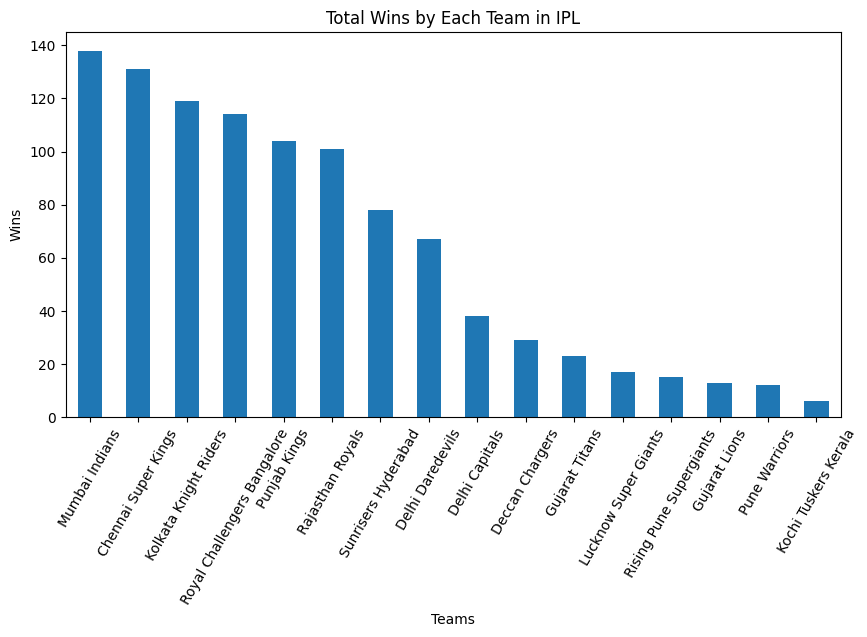

In [15]:
team_wins.plot(kind='bar', figsize=(10,5))
plt.title("Total Wins by Each Team in IPL")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.xticks(rotation=60)
plt.show()

### 📊 Key Insight:
Mumbai Indians (MI) and Chennai Super Kings (CSK) emerge as the most successful teams, consistently leading in total match victories across seasons.

## 🪙 Impact of Toss on Match Outcome

### ❓ Business Question:
Does winning the toss influence the chances of winning the match in IPL?

### 💡 Solution:
We compare the toss winner with the match winner to analyze if there is any significant impact.


### ⚙️ Step 1: Create Comparison Column

We create a new column to check whether the toss-winning team also won the match.

In [16]:
ipl['toss_win_match_win'] = (ipl['toss_winner'] == ipl['match_winner'])
ipl['toss_win_match_win'].value_counts()


toss_win_match_win
False    528
True     477
Name: count, dtype: int64

### 📈 Step 2: Calculate Winning Percentage

Here, we calculate the percentage of matches where the toss winner also won the match.

In [17]:
total = 528 + 477

false_perc = (528 / total) * 100
true_perc = (477 / total) * 100

print(false_perc, true_perc)

52.537313432835816 47.462686567164184


### 📊 Visualization: Toss Impact on Match Result

This bar chart shows the number of matches where the toss-winning team either won or lost the match,helping us understand the actual impact of the toss.

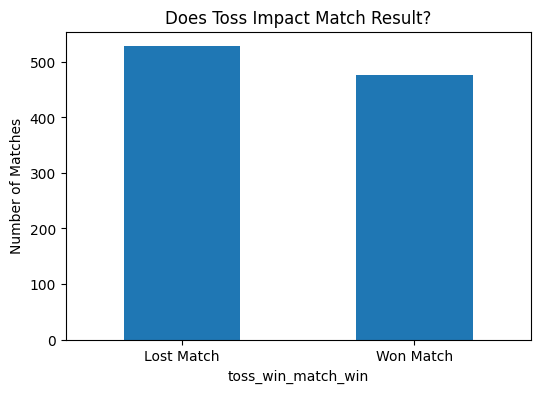

In [18]:
import matplotlib.pyplot as plt

ipl['toss_win_match_win'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.xticks([0,1], ['Lost Match', 'Won Match'], rotation=0)
plt.title("Does Toss Impact Match Result?")
plt.ylabel("Number of Matches")
plt.show()

### 📊 Insight:
Teams that win the toss do not have a significant advantage, as they lost 528 matches and won 477 matches after winning the toss, indicating that match performance matters more than the toss outcome.

## 🏟️ Venue Influence on Match Outcomes

### ❓ Business Question:
Do certain stadiums favor high-scoring or low-scoring matches in the IPL?


### ✅ Step 1: Create total average score per venue

In [19]:
ipl['avg_total_score'] = ipl['avg_1st_innings'] + ipl['avg_2nd_innings']
ipl['avg_total_score']

0       338.0
1       338.0
2       313.0
3       313.0
4       324.0
        ...  
1019    314.0
1020    328.0
1021    310.0
1022    325.0
1023    324.0
Name: avg_total_score, Length: 1005, dtype: float64

### ✅ Step 2: Group by venue

In [20]:
venue_score = ipl.groupby('venue')['avg_total_score'].mean().sort_values(ascending=False)

print(venue_score.head(10))   # High scoring
print(venue_score.tail(10))   # Low scoring

venue
Barsapara Cricket Stadium, Guwahati                                 365.0
Brabourne Stadium, Mumbai                                           345.0
Narendra Modi Stadium, Ahmedabad                                    338.0
Arun Jaitley Stadium, Delhi                                         336.0
Himachal Pradesh Cricket Association Stadium, Dharamsala            335.0
Saurashtra Cricket Association Stadium                              332.0
Wankhede Stadium, Mumbai                                            328.0
Barabati Stadium                                                    326.0
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh    325.0
Green Park                                                          324.0
Name: avg_total_score, dtype: float64
venue
St George's Park                                                         290.0
Kingsmead                                                                290.0
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium 

#### 🔥 High scoring venues

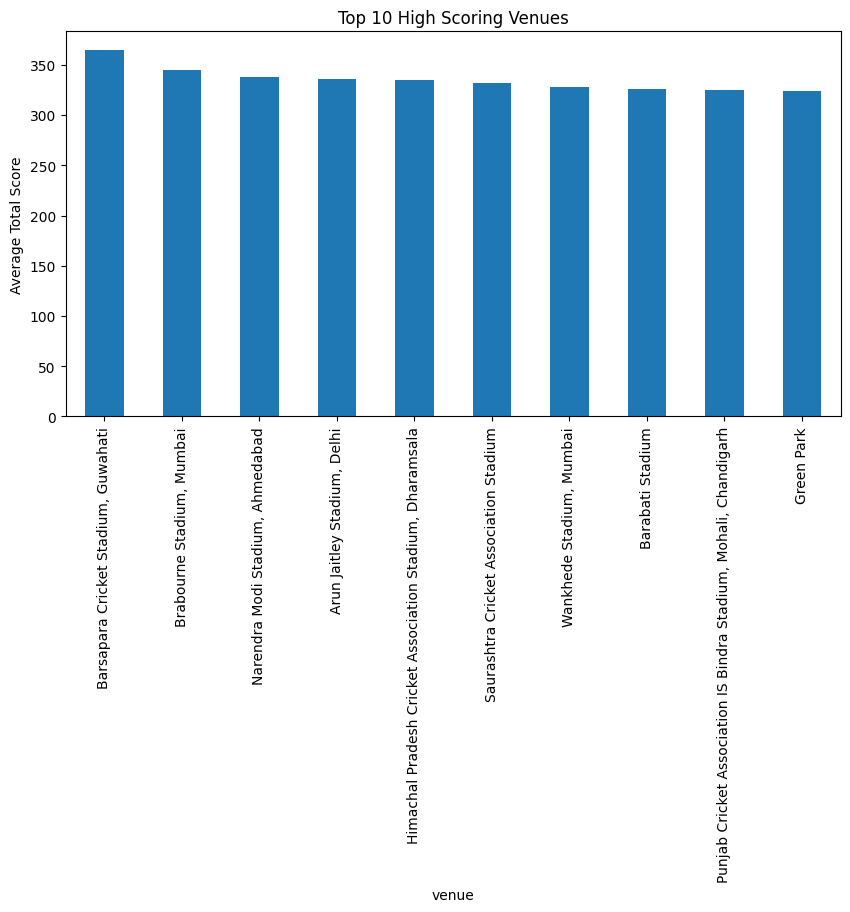

In [21]:
venue_score.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 High Scoring Venues")
plt.ylabel("Average Total Score")
plt.xticks(rotation=90)
plt.show()

#### ❄️ Low scoring venues

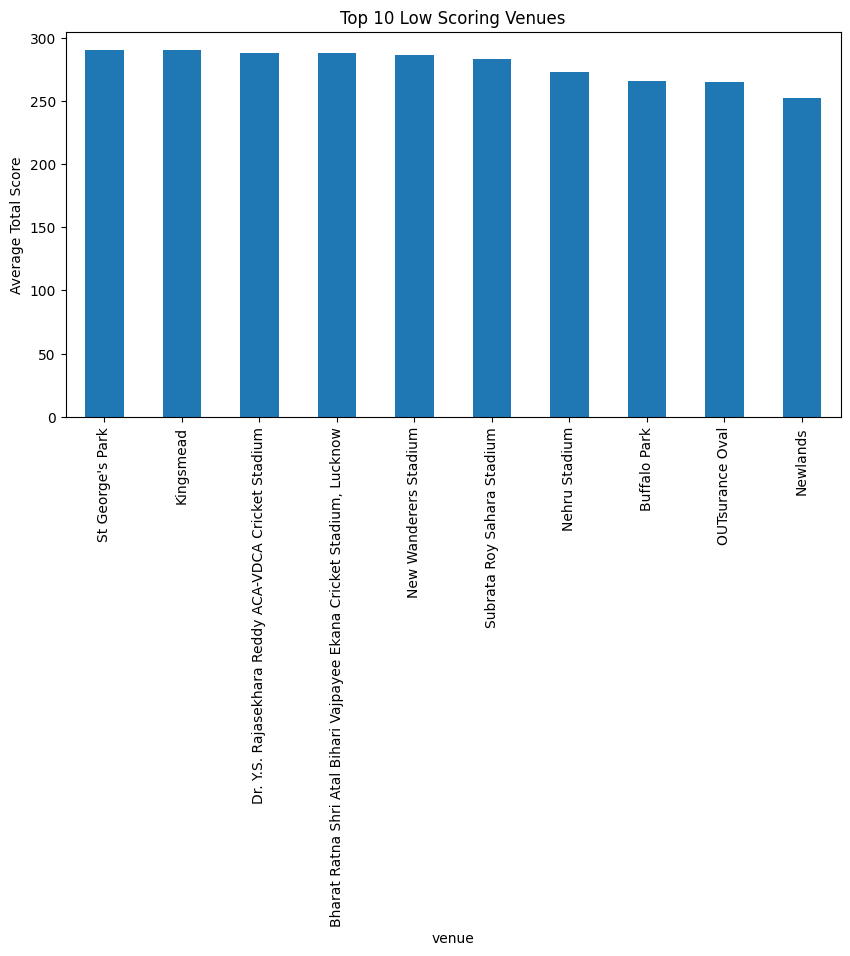

In [22]:
venue_score.tail(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Low Scoring Venues")
plt.ylabel("Average Total Score")
plt.xticks(rotation=90)
plt.show()

“Matches played outside India show different scoring patterns, highlighting how pitch conditions vary significantly across countries.”

### 📊 Insight:
Match outcomes are influenced by venue conditions, as some stadiums consistently produce high-scoring games while others favor low-scoring matches, indicating the impact of pitch behavior.



## 🎯 Team Consistency Analysis

### ❓ Business Question:
How consistent are teams in their performance across different IPL seasons?

###  Step 1: Calculate Season-wise Wins

We count the number of matches won by each team in every season to analyze performance consistency.

In [23]:
team_season_wins = ipl.groupby(['season', 'match_winner']).size().reset_index(name='wins')
team_season_wins.head()

,season,match_winner,wins
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Daredevils,7
3,2008,Kolkata Knight Riders,6
4,2008,Mumbai Indians,7


### 📊 Step 2: Create Pivot Table

We create a pivot table to summarize season-wise wins for each team, making it easier to compare performance across seasons.

In [24]:
pivot = team_season_wins.pivot(index='season', columns='match_winner', values='wins')
pivot


match_winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,,,
2008,9.0,2.0,NaN,7.0,NaN,NaN,NaN,6.0,NaN,7.0,NaN,10.0,13.0,NaN,4.0,NaN
2009,8.0,9.0,NaN,10.0,NaN,NaN,NaN,3.0,NaN,5.0,NaN,7.0,5.0,NaN,9.0,NaN
2010,9.0,8.0,NaN,7.0,NaN,NaN,NaN,7.0,NaN,11.0,NaN,3.0,6.0,NaN,8.0,NaN
2011,11.0,6.0,NaN,4.0,NaN,NaN,6.0,8.0,NaN,10.0,4.0,7.0,6.0,NaN,10.0,NaN
2012,10.0,4.0,NaN,11.0,NaN,NaN,NaN,12.0,NaN,10.0,4.0,8.0,7.0,NaN,8.0,NaN
2013,12.0,NaN,NaN,3.0,NaN,NaN,NaN,6.0,NaN,13.0,4.0,8.0,11.0,NaN,8.0,9.0
2014,10.0,NaN,NaN,2.0,NaN,NaN,NaN,11.0,NaN,7.0,NaN,12.0,6.0,NaN,5.0,6.0
2015,10.0,NaN,NaN,5.0,NaN,NaN,NaN,7.0,NaN,10.0,NaN,2.0,7.0,NaN,8.0,7.0
2016,NaN,NaN,NaN,7.0,9.0,NaN,NaN,8.0,NaN,7.0,NaN,4.0,NaN,5.0,9.0,11.0


### 📈 Step 3: Visualize Season-wise Performance

We create a graph to visualize team performance across seasons, helping identify consistency and trends.

In [25]:
pivot = team_season_wins.pivot(index='season', columns='match_winner', values='wins')

fig = px.line(team_season_wins, x='season', y='wins', color='match_winner',
              title="Team Performance Over Seasons",
              labels={'season': 'Season', 'wins': 'Number of Wins', 'match_winner': 'Teams'},
              markers=True,
              height=600,
              width=1200)
fig.show()

### 🧠 Insight

Some teams maintain stable performance across seasons with consistent win counts, while others show significant fluctuations, indicating inconsistency.

## ⚔️ Head-to-Head Rivalry Strength

### ❓ Business Question:
Do certain teams dominate specific opponents in head-to-head IPL matchups?

### ⚙️ Step 1: Create Match Pairs

We create team pairs (Team A vs Team B) for each match to analyze head-to-head performance.

In [26]:
ipl['match_pair'] = ipl.apply(lambda x: ' vs '.join(sorted([x['team1'], x['team2']])), axis=1)
ipl['match_pair']

0                   Chennai Super Kings vs Gujarat Titans
1                        Gujarat Titans vs Mumbai Indians
2                  Lucknow Super Giants vs Mumbai Indians
3                   Chennai Super Kings vs Gujarat Titans
4           Gujarat Titans vs Royal Challengers Bangalore
                              ...                        
1019             Deccan Chargers vs Kolkata Knight Riders
1020        Mumbai Indians vs Royal Challengers Bangalore
1021                 Delhi Daredevils vs Rajasthan Royals
1022                  Chennai Super Kings vs Punjab Kings
1023    Kolkata Knight Riders vs Royal Challengers Ban...
Name: match_pair, Length: 1005, dtype: object

### 🔢 Step 2: Calculate Total Matches

We count the total number of matches played between each team pair to analyze the strength of head-to-head rivalries.

In [27]:
total_matches = ipl.groupby('match_pair').size().reset_index(name='total_matches')
total_matches.head()

,match_pair,total_matches
0,Chennai Super Kings vs Deccan Chargers,10
1,Chennai Super Kings vs Delhi Capitals,11
2,Chennai Super Kings vs Delhi Daredevils,18
3,Chennai Super Kings vs Gujarat Titans,5
4,Chennai Super Kings vs Kochi Tuskers Kerala,2


### 🏆 Step 3: Calculate Wins (Team-wise)

We calculate the number of matches won by each team against their opponents to evaluate head-to-head performance.

In [28]:
wins = ipl.groupby(['match_pair', 'match_winner']).size().reset_index(name='wins')
wins.head()


,match_pair,match_winner,wins
0,Chennai Super Kings vs Deccan Chargers,Chennai Super Kings,6
1,Chennai Super Kings vs Deccan Chargers,Deccan Chargers,4
2,Chennai Super Kings vs Delhi Capitals,Chennai Super Kings,7
3,Chennai Super Kings vs Delhi Capitals,Delhi Capitals,4
4,Chennai Super Kings vs Delhi Daredevils,Chennai Super Kings,12


### 🔗 Step 4: Merge Data

We merge the total matches and team-wise wins data to create a complete head-to-head analysis dataset.

In [29]:
h2h = pd.merge(wins, total_matches, on='match_pair')
h2h.head()

,match_pair,match_winner,wins,total_matches
0,Chennai Super Kings vs Deccan Chargers,Chennai Super Kings,6,10
1,Chennai Super Kings vs Deccan Chargers,Deccan Chargers,4,10
2,Chennai Super Kings vs Delhi Capitals,Chennai Super Kings,7,11
3,Chennai Super Kings vs Delhi Capitals,Delhi Capitals,4,11
4,Chennai Super Kings vs Delhi Daredevils,Chennai Super Kings,12,18


### 📊 Step 5: Calculate Win Percentage

We calculate the win percentage for each team against their opponents to identify dominance in head-to-head matchups.

In [30]:
h2h['win_percentage'] = (h2h['wins'] / h2h['total_matches']) * 100
h2h.sort_values(by='win_percentage', ascending=False).head(10)

,match_pair,match_winner,wins,total_matches,win_percentage
28,Deccan Chargers vs Kochi Tuskers Kerala,Deccan Chargers,1,1,100.0
86,Gujarat Lions vs Sunrisers Hyderabad,Sunrisers Hyderabad,5,5,100.0
89,Gujarat Titans vs Lucknow Super Giants,Gujarat Titans,4,4,100.0
101,Kochi Tuskers Kerala vs Mumbai Indians,Kochi Tuskers Kerala,1,1,100.0
102,Kochi Tuskers Kerala vs Pune Warriors,Pune Warriors,1,1,100.0
100,Kochi Tuskers Kerala vs Kolkata Knight Riders,Kochi Tuskers Kerala,2,2,100.0
45,Delhi Capitals vs Lucknow Super Giants,Lucknow Super Giants,3,3,100.0
103,Kochi Tuskers Kerala vs Punjab Kings,Punjab Kings,1,1,100.0
106,Kochi Tuskers Kerala vs Royal Challengers Bang...,Royal Challengers Bangalore,2,2,100.0
107,Kolkata Knight Riders vs Lucknow Super Giants,Lucknow Super Giants,3,3,100.0


### 📊 Step 7: Visualize Top Rivalries (Plotly)

We create an interactive bar chart using Plotly to visualize top rivalries based on win percentage, focusing on team pairs with more than 20 matches.

In [31]:
top_pairs = h2h[h2h['total_matches'] > 20]

fig = px.bar(top_pairs, x='match_pair', y='win_percentage', color='match_winner',
             title="Top Rivalries - Win %",
             labels={'match_pair': 'Match Pair', 'win_percentage': 'Win Percentage', 'match_winner': 'Match Winner'},
             height=800,
             width=1200)

fig.update_xaxes(tickangle=90)
fig.show()

In [32]:

ipl.sample(5)

,season,team1,team2,toss_winner,toss_decision,match_winner,winner_wickets,winner_runs,player_of_match,venue,team1_win_percentage_against_team2,avg_1st_innings,avg_2nd_innings,toss_win_match_win,avg_total_score,match_pair
284,2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,field,Mumbai Indians,0.0,46.0,RG Sharma,"MA Chidambaram Stadium, Chepauk, Chennai",44.44,163.0,150.0,False,313.0,Chennai Super Kings vs Mumbai Indians
854,2010,Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,Deccan Chargers,0.0,11.0,A Symonds,Feroz Shah Kotla,36.36,162.0,148.0,True,310.0,Deccan Chargers vs Delhi Daredevils
669,2013,Sunrisers Hyderabad,Chennai Super Kings,Sunrisers Hyderabad,bat,Chennai Super Kings,5.0,0.0,MS Dhoni,"MA Chidambaram Stadium, Chepauk, Chennai",26.32,163.0,150.0,False,313.0,Chennai Super Kings vs Sunrisers Hyderabad
178,2021,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Kolkata Knight Riders,9.0,0.0,CV Varun,"Zayed Cricket Stadium, Abu Dhabi",56.25,159.0,150.0,False,309.0,Kolkata Knight Riders vs Royal Challengers Ban...
828,2011,Kolkata Knight Riders,Kochi Tuskers Kerala,Kolkata Knight Riders,field,Kochi Tuskers Kerala,0.0,6.0,DPMD Jayawardene,"Eden Gardens, Kolkata",0.00,164.0,150.0,False,314.0,Kochi Tuskers Kerala vs Kolkata Knight Riders
